# Syngo: LA Dilation

In [225]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import os

In [226]:
data_dir = 'data/dataset/Lee_Echo_Syngo'
adler = pd.read_csv(os.path.join(data_dir, 'Adler.csv'))
analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
analytics_study = pd.read_csv(os.path.join(data_dir, 'AnalyticsStudy.csv'))
department = pd.read_csv(os.path.join(data_dir, 'Department.csv'))
field_map = pd.read_csv(os.path.join(data_dir, 'FieldMap.csv'))
measurement_type = pd.read_csv(os.path.join(data_dir, 'MeasurementType.csv'))
modalities = pd.read_csv(os.path.join(data_dir, 'Modalities.csv'))
observations = pd.read_csv(os.path.join(data_dir, 'Observations.csv'))
study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))

/tmp/ipykernel_21168/1852141919.py:3: DtypeWarning: Columns (18,19,23,24,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
/tmp/ipykernel_21168/1852141919.py:10: DtypeWarning: Columns (6,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))


In [227]:
aws_uhn = pd.read_csv('aws/aws_uhn.csv', index_col=0)
print(aws_uhn.shape)

(320854, 9)


In [263]:
syn_df = observations.loc[observations['Name'] == 'LA_size-ASE_obs']
syn_df = syn_df.dropna(subset=['Value'])

In [264]:
syn_df.head()

,StudyRef,ObservationID,Value,Type,Name
23,1000750,54,severely_dilated,ABNORMAL,LA_size-ASE_obs
72,1000751,54,dilated,OTHER,LA_size-ASE_obs
88,1000846,54,normal,OTHER,LA_size-ASE_obs
198,1000712,54,moderately_dilated,ABNORMAL,LA_size-ASE_obs
338,1000715,54,dilated,OTHER,LA_size-ASE_obs


In [265]:
print(len(syn_df))
syn_df['Value'].value_counts()

89642


Value
normal                44780
dilated               19669
mildly_dilated        10772
severely_dilated       8089
moderately_dilated     3922
cardiac_transplant     2410
Name: count, dtype: int64

In [266]:
# list of values to drop
values_to_drop = ['cardiac_transplant']

# filter the DataFrame
syn_df = syn_df[~syn_df['Value'].isin(values_to_drop)]

mapping_binary = {
    'normal': 'normal',
    'dilated': 'dilated',
    'mildly_dilated': 'dilated',
    'severely_dilated': 'dilated',
    'moderately_dilated': 'dilated',
}

In [267]:
label_col = 'LA_Dilated_Binary'
syn_df[label_col] = syn_df['Value'].map(mapping_binary)

In [268]:
print(len(syn_df))
syn_df[label_col].value_counts()

87232


LA_Dilated_Binary
normal     44780
dilated    42452
Name: count, dtype: int64

In [269]:
# Create a boolean mask to identify matching StudyRef values
matching_mask = syn_df['StudyRef'].isin(aws_uhn['STUDY_REF'])

# Count the number of matches (True values)
number_of_matches = matching_mask.sum()

# Get the total number of unique studies in mv_obs for context
total_unique_studies = syn_df['StudyRef'].nunique()

print(f"\nTotal unique StudyRef values in syn_df: {total_unique_studies}")
print(f"Number of 'StudyRef' values from syn_df that are in aws_uhn: {number_of_matches}")
print(f"Percentage of matching studies: {(number_of_matches / total_unique_studies) * 100:.2f}%")


Total unique StudyRef values in syn_df: 86300
Number of 'StudyRef' values from syn_df that are in aws_uhn: 41824
Percentage of matching studies: 48.46%


In [270]:
import pandas as pd

# Assuming 'mv_obs' and 'aws_uhn' are your DataFrames loaded as in the screenshots.

# Step 1: Merge the two DataFrames
# We'll merge 'mv_obs' with 'aws_uhn' using 'StudyRef' and 'STUDY_REF' as the keys.
merged_df = pd.merge(syn_df, aws_uhn, left_on='StudyRef', right_on='STUDY_REF', how='inner')

# Step 2: Define the desired columns in the correct order
final_columns = [
    'STUDY_REF',
    's3_key',
    'Value',
    label_col,
    'PATIENT_ID',
    'STUDY_DATE',
    'STUDY_TIME',
    'DeidentifiedStudyID',
    'OriginalStudyID'
]

# # Step 3: Create the new table with only the specified columns
syn_df_labels = merged_df[final_columns]

# convert numeric date to datetime
syn_df_labels['STUDY_DATE'] = pd.to_datetime(
    syn_df_labels['STUDY_DATE'].astype(str), 
    format='%Y%m%d'
)

# now sortable by date
syn_df_labels = syn_df_labels.sort_values('STUDY_DATE')
syn_df_labels['STUDY_DATE'] = syn_df_labels['STUDY_DATE'].dt.strftime('%Y-%m-%d')

/tmp/ipykernel_21168/1878314981.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syn_df_labels['STUDY_DATE'] = pd.to_datetime(


In [271]:
print(syn_df_labels.shape)
print(syn_df_labels[label_col].value_counts())
print(syn_df_labels.columns)
display(syn_df_labels.head())

(42611, 9)
LA_Dilated_Binary
normal     21874
dilated    20737
Name: count, dtype: int64
Index(['STUDY_REF', 's3_key', 'Value', 'LA_Dilated_Binary', 'PATIENT_ID',
       'STUDY_DATE', 'STUDY_TIME', 'DeidentifiedStudyID', 'OriginalStudyID'],
      dtype='object')


,STUDY_REF,s3_key,Value,LA_Dilated_Binary,PATIENT_ID,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID
0,1000750,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089/,severely_dilated,dilated,2132997,2015-07-22,80635.0,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,1.3.12.2.1107.5.8.9.1002655211149138.20150722120043279
59,1001258,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196786.2224480/,dilated,dilated,2700382,2015-07-22,140531.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196786.2224480,1.3.12.2.1107.5.8.9.1002655211149138.20150722184340673
57,1001177,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725196383.4284757/,mildly_dilated,dilated,2713602,2015-07-22,131220.0,1.2.276.0.7230010.3.1.2.895693665.1.1725196383.4284757,1.3.12.2.1107.5.8.9.1002655211149138.20150722165624370
56,1001176,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714/,mildly_dilated,dilated,4291335,2015-07-22,131241.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714,1.3.12.2.1107.5.8.9.1002655211149138.20150722154701631
55,1001170,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196323.2222888/,dilated,dilated,0272073,2015-07-22,130918.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196323.2222888,1.3.12.2.1107.5.8.9.1002655211149138.20150722160045699


# HeartLab: LA Dilation

In [272]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import os

In [273]:
data_dir = 'data/dataset'

msmt_defs = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_DEFINITIONS.csv'))
msmt_formula = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_FORMULA.csv'))
msmt_groups = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_GROUPS.csv'))
msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))
msmt_lists = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_LISTS.csv'))
msmt = pd.read_csv(os.path.join(data_dir,'MEASUREMENTS.csv'))

findings = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDINGS.csv'))
finding_groups = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_GROUPS.csv'))
finding_intersects = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_INTERSECTS.csv'))

patients = pd.read_csv(os.path.join(data_dir,'Patients_No_PHI.csv'))
reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))

/tmp/ipykernel_21168/2801898404.py:6: DtypeWarning: Columns (7,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))
/tmp/ipykernel_21168/2801898404.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
/tmp/ipykernel_21168/2801898404.py:16: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
/tmp/ipykernel_21168/2801898404.py:17: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))


In [274]:
hl_link = pd.read_csv(os.path.join(data_dir, 'heartlab_rep_study_video.csv'))

In [275]:
hl_link.head()

,OriginalStudyID,OriginalPatientID,DeidentifiedStudyID,DeidentifiedPatientID,REP_ID,STUDY_DATE,STUDY_ID,SERI_ID,STUDY_INSTANCE_UID
0,1.2.840.113543.6.6.2.0.97083308851.20060302142809,3266450,1.2.276.0.7230010.3.1.2.1714578744.1.1703334530.11867061,00877fe5-b4ab-4df8-b6f1-68b947cec98d,81653.0,03/02/06 14:47:59,85175,167669,1.2.840.113543.6.6.2.0.97083308851.20060302142809
1,1.2.840.113663.1500.1.323664363.1.1.20140731.71250.953,2373936,1.2.276.0.7230010.3.1.2.1714512485.1.1703517296.18188851,8f9ab5ad-e865-4896-848b-dace75487884,352424.0,07/31/14 07:12:50,429897,849808,1.2.840.113663.1500.1.323664363.1.1.20140731.71250.953
2,1.2.840.113663.1500.1.251138317.1.1.20101020.145112.968,3400831,1.2.276.0.7230010.3.1.2.845494328.1.1703473583.20140024,62e5a193-0393-4210-9bd6-852d361f4734,243023.0,10/20/10 14:51:12,257826,504445,1.2.840.113663.1500.1.251138317.1.1.20101020.145112.968
3,1.2.840.113619.2.185.2475.1288968365.0.2,2866816,1.2.276.0.7230010.3.1.2.859333938.1.1703349794.12277579,a06b4a83-3fc9-4c10-ad01-fab2d52d9b6d,244657.0,11/05/10 09:46:05,259779,508538,1.2.840.113619.2.185.2475.1288968365.0.2
4,1.2.840.113619.2.185.2551.1376654311.0.2,2003428,1.2.276.0.7230010.3.1.2.811753780.1.1703356738.12653270,c204d4f9-2acb-463d-85fb-8a659ff9221b,324231.0,08/16/13 12:58:31,363739,756286,1.2.840.113619.2.185.2551.1376654311.0.2


In [276]:
aws_heartlab = pd.read_csv('aws/aws_heartlab_0806.csv', index_col=0)
print(aws_heartlab.shape)

(215113, 12)


In [277]:
finding_intersects = finding_intersects.merge(
    findings[['ID', 'HLCODE']], 
    left_on='FIN_ID', 
    right_on='ID', 
    how='left'
).drop(columns='ID_y').rename(columns={'ID_x': 'ID'})


In [278]:
codes = finding_intersects['HLCODE'].str.strip().str.lower()
# hl_df = finding_intersects[codes.str.contains('tricuspid valve.*regurgitation', na=False)]
hl_df = finding_intersects[codes.str.contains('la cavity size', na=False)]

In [279]:
hl_df['HLCODE'].value_counts()

HLCODE
left atrium^morphology^la cavity size^normal                     44920
left atrium^morphology^la cavity size^mildly dilated             39163
left atrium^morphology^la cavity size^dilated                    23223
left atrium^morphology^la cavity size^moderately dilated         12696
local^left atrium^morphology^la cavity size^upper normal^1561     7541
left atrium^morphology^la cavity size^severely dilated            7018
left atrium^morphology^la cavity size^abnormally small              68
Name: count, dtype: int64

In [280]:
hl_df['HLCODE'].unique()

array(['left atrium^morphology^la cavity size^mildly dilated',
       'left atrium^morphology^la cavity size^normal',
       'left atrium^morphology^la cavity size^moderately dilated',
       'local^left atrium^morphology^la cavity size^upper normal^1561',
       'left atrium^morphology^la cavity size^dilated',
       'left atrium^morphology^la cavity size^severely dilated',
       'left atrium^morphology^la cavity size^abnormally small'],
      dtype=object)

In [281]:
keep = [
    'left atrium^morphology^la cavity size^mildly dilated',
    'left atrium^morphology^la cavity size^normal',
    'left atrium^morphology^la cavity size^moderately dilated',
    'local^left atrium^morphology^la cavity size^upper normal^1561',
    'left atrium^morphology^la cavity size^dilated',
    'left atrium^morphology^la cavity size^severely dilated'
]

hl_df = hl_df[hl_df['HLCODE'].isin(keep)].copy()

In [282]:
mapping_two = {
    'left atrium^morphology^la cavity size^mildly dilated': 'dilated',
    'left atrium^morphology^la cavity size^normal': 'normal',
    'left atrium^morphology^la cavity size^moderately dilated': 'dilated',
    'local^left atrium^morphology^la cavity size^upper normal^1561': 'normal',
    'left atrium^morphology^la cavity size^dilated': 'dilated',
    'left atrium^morphology^la cavity size^severely dilated': 'dilated'
}

hl_df[label_col] = hl_df['HLCODE'].map(mapping_two)

In [283]:
print(hl_df[label_col].dropna().value_counts())

LA_Dilated_Binary
dilated    82100
normal     52461
Name: count, dtype: int64


In [284]:
# REP_IDs that appear in the hl_df dataframe
hl_ids = hl_df['REP_ID'].dropna().unique()
print(len(hl_ids))

# Grab columns from the hl_link dataframes using REP_IDs
hl_df_labels = hl_link[hl_link['REP_ID'].isin(hl_ids)].copy()

134557


In [285]:
hl_df_labels = hl_df.merge(
    hl_df_labels,
    on='REP_ID',
    how='inner',
    suffixes=('', '_drop')  # keep REP_ID as-is, add suffix to duplicates
)

# Remove the duplicate REP_ID column if created
if 'REP_ID_drop' in hl_df_labels.columns:
    hl_df_labels = hl_df_labels.drop(columns=['REP_ID_drop'])

hl_df_labels = hl_df_labels.merge(
    aws_heartlab[['OriginalStudyID', 's3_key']],  # only needed columns
    on='OriginalStudyID',
    how='left'
)

hl_df_labels = hl_df_labels.dropna(subset=['s3_key'])

# convert STUDY_DATE to datetime objects
hl_df_labels['STUDY_DATE'] = pd.to_datetime(
    hl_df_labels['STUDY_DATE'], 
    format='%m/%d/%y %H:%M:%S'  # matches "01/20/09 10:29:09"
)



# now you can sort
hl_df_labels = hl_df_labels.sort_values('STUDY_DATE')
hl_df_labels['STUDY_DATE'] = hl_df_labels['STUDY_DATE'].dt.strftime('%Y-%m-%d')

hl_df_labels = hl_df_labels.rename(
    columns={'OriginalPatientID': 'PATIENT_ID'}
)

print(hl_df_labels.columns)
print(hl_df_labels.shape)
display(hl_df_labels.head())

Index(['ID', 'FIN_ID', 'PHAS_ID', 'NOTE', 'SEQA_ID', 'SEQB_ID', 'SEQC_ID',
       'REP_ID', 'SEQD_ID', 'STRUCTURE_GROUP_SEQ', 'HLCODE',
       'LA_Dilated_Binary', 'OriginalStudyID', 'PATIENT_ID',
       'DeidentifiedStudyID', 'DeidentifiedPatientID', 'STUDY_DATE',
       'STUDY_ID', 'SERI_ID', 'STUDY_INSTANCE_UID', 's3_key'],
      dtype='object')
(91648, 21)


,ID,FIN_ID,PHAS_ID,NOTE,SEQA_ID,SEQB_ID,SEQC_ID,REP_ID,SEQD_ID,STRUCTURE_GROUP_SEQ,HLCODE,LA_Dilated_Binary,OriginalStudyID,PATIENT_ID,DeidentifiedStudyID,DeidentifiedPatientID,STUDY_DATE,STUDY_ID,SERI_ID,STUDY_INSTANCE_UID,s3_key
135,15837,64,1,NaN,NaN,NaN,NaN,2734,NaN,NaN,left atrium^morphology^la cavity size^mildly dilated,dilated,1.2.840.113619.2.98.1722.1076392656.0.953,2988134,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,871c4367-6320-494b-8567-2052a62ce9a3,2004-02-10,27370,29195,1.2.840.113619.2.98.1722.1076392656.0.953,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/
274,29047,63,1,NaN,NaN,NaN,NaN,3491,NaN,NaN,left atrium^morphology^la cavity size^dilated,dilated,1.2.840.113543.6.6.2.0.37283301485.20040218110000,2481240,1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420,8c89cfc3-33cc-44ed-b389-32ba52c6fa53,2004-02-18,27932,30102,1.2.840.113543.6.6.2.0.37283301485.20040218110000,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420/
1213,270151,62,1,NaN,NaN,NaN,NaN,16908,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,1051718,1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064,b183fe1a-566f-4b01-b49d-90ee44b0f078,2004-07-06,38087,47498,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064/
1212,270317,62,1,NaN,NaN,NaN,NaN,16918,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,3000666,1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584,0ed3ee1a-ee01-45f7-92fd-96eac5045ffc,2004-07-06,38096,47514,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584/
1221,285789,62,1,NaN,NaN,NaN,NaN,17671,NaN,NaN,left atrium^morphology^la cavity size^normal,normal,1.2.840.113680.1.103.51602.1089741645.391708,3149598,1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674,73e46460-bbcb-4907-9291-25428a8e913d,2004-07-13,38600,48390,1.2.840.113680.1.103.51602.1089741645.391708,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674/


# Combine

In [286]:
# Columns you want to keep
keep_cols = [
    'STUDY_REF','REP_ID','HLCODE', 'Value', label_col ,'s3_key',  'STUDY_DATE',
    'STUDY_TIME', 'DeidentifiedStudyID', 'OriginalStudyID',
    'PATIENT_ID', 'DeidentifiedPatientID', 'SERI_ID', 'STUDY_ID',
    'STUDY_INSTANCE_UID'
]

# Combine both dataframes
uhn_df = pd.concat([syn_df_labels, hl_df_labels], ignore_index=True, sort=False)

# Drop overlapping OriginalStudyIDs (keep first occurrence)
uhn_df = uhn_df.drop_duplicates(subset='OriginalStudyID', keep='first')

# Restrict to selected columns
uhn_df = uhn_df.reindex(columns=keep_cols)

# Drop rows where there is no s3 key
uhn_df = uhn_df.dropna(subset=['s3_key'])

# Ensure STUDY_DATE is datetime before sorting
uhn_df['STUDY_DATE'] = pd.to_datetime(uhn_df['STUDY_DATE'], errors='coerce')

# Sort by STUDY_DATE (earliest first)
uhn_df = uhn_df.sort_values('STUDY_DATE')

print(uhn_df.shape)
display(uhn_df.head())


(132901, 15)


,STUDY_REF,REP_ID,HLCODE,Value,LA_Dilated_Binary,s3_key,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID,PATIENT_ID,DeidentifiedPatientID,SERI_ID,STUDY_ID,STUDY_INSTANCE_UID
42611,NaN,2734.0,left atrium^morphology^la cavity size^mildly dilated,NaN,dilated,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/,2004-02-10,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,1.2.840.113619.2.98.1722.1076392656.0.953,2988134,871c4367-6320-494b-8567-2052a62ce9a3,29195.0,27370.0,1.2.840.113619.2.98.1722.1076392656.0.953
42612,NaN,3491.0,left atrium^morphology^la cavity size^dilated,NaN,dilated,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420/,2004-02-18,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420,1.2.840.113543.6.6.2.0.37283301485.20040218110000,2481240,8c89cfc3-33cc-44ed-b389-32ba52c6fa53,30102.0,27932.0,1.2.840.113543.6.6.2.0.37283301485.20040218110000
42614,NaN,16918.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584/,2004-07-06,NaN,1.2.276.0.7230010.3.1.2.811753780.1.1703404411.13767584,1.2.840.113663.1298.56555945.1.26060.20040706.1130203,3000666,0ed3ee1a-ee01-45f7-92fd-96eac5045ffc,47514.0,38096.0,1.2.840.113663.1298.56555945.1.26060.20040706.1130203
42613,NaN,16908.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064/,2004-07-06,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703404758.19383064,1.2.840.113663.1298.56555945.1.8341.20040706.1112016,1051718,b183fe1a-566f-4b01-b49d-90ee44b0f078,47498.0,38087.0,1.2.840.113663.1298.56555945.1.8341.20040706.1112016
42615,NaN,17671.0,left atrium^morphology^la cavity size^normal,NaN,normal,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674/,2004-07-13,NaN,1.2.276.0.7230010.3.1.2.845494328.1.1703536309.20915674,1.2.840.113680.1.103.51602.1089741645.391708,3149598,73e46460-bbcb-4907-9291-25428a8e913d,48390.0,38600.0,1.2.840.113680.1.103.51602.1089741645.391708


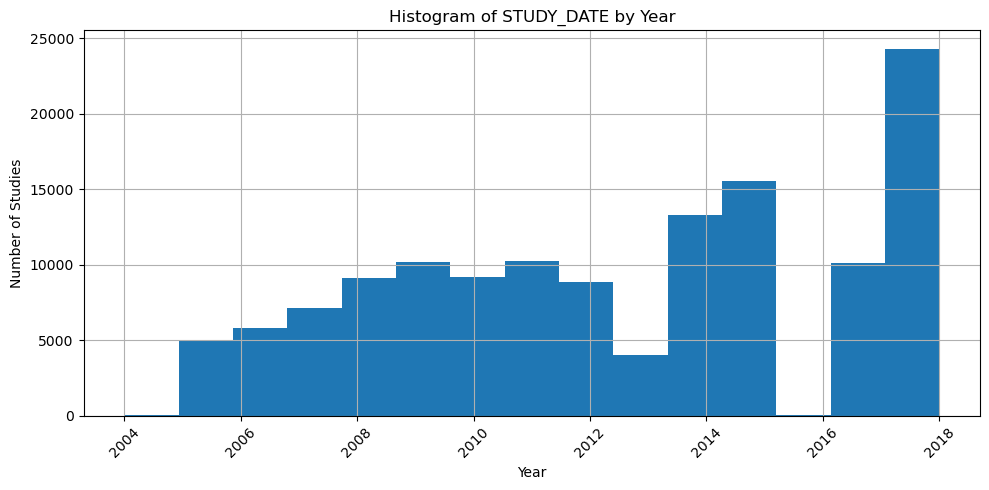

In [287]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure STUDY_DATE is datetime
uhn_df['STUDY_DATE'] = pd.to_datetime(uhn_df['STUDY_DATE'], errors='coerce')

# Extract year
uhn_df['YEAR'] = uhn_df['STUDY_DATE'].dt.year

# Plot histogram
plt.figure(figsize=(10,5))
uhn_df['YEAR'].dropna().astype(int).hist(bins=uhn_df['YEAR'].nunique())
plt.xlabel('Year')
plt.ylabel('Number of Studies')
plt.title('Histogram of STUDY_DATE by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [255]:
# Final label counts for the selected condition
uhn_df[label_col].value_counts()

Dilated_Binary
dilated    75112
normal     57789
Name: count, dtype: int64

In [294]:
uhn_df.to_csv('csv/uhn_lad_0919.csv')

# Create Splits

In [186]:
import pandas as pd
from pathlib import Path

all_es = pd.read_parquet('all_es_combined.parquet')

In [191]:
# Create a new DataFrame called 'a4c_df' by filtering 'all_es'
# all_es = combined_df
a4c_videos = all_es[all_es['pred_view'] == 'a4c'].copy()

# This regex finds 'echo-study', 'echo-study-1', or 'echo-study-2',
# and then captures the sequence of characters that follows until the next slash.
regex_pattern = r'results/echo-study(?:-[12])?/([^/]+)'

# Use .str.extract() to pull out the captured group (the Study ID)
a4c_videos['DeidentifiedStudyID'] = a4c_videos['png_uri'].str.extract(regex_pattern)

a4c_videos = a4c_videos[['DeidentifiedStudyID', 'mp4_uri_corrected']].rename(
    columns={'mp4_uri_corrected': 'URI'}
)

In [291]:
print(a4c_videos.shape)
display(a4c_videos.head())

(2976025, 2)


,DeidentifiedStudyID,URI
3,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111392.10353346.mp4
5,1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773/1.2.276.0.7230010.3.1.3.1714512485.1.1703119859.10459774/1.2.276.0.7230010.3.1.4.1714512485.1.1703120151.10464936.mp4
9,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.811753780.1.1703111413.8215093.mp4
11,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.811753780.1.1703111387.8215053.mp4
13,1.2.276.0.7230010.3.1.2.1714512485.1.1703113062.10354034,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703113062.10354034/1.2.276.0.7230010.3.1.3.1714512485.1.1703113062.10354035/1.2.276.0.7230010.3.1.4.1714512485.1.1703113992.10362168.mp4


In [295]:
combined_labels = pd.read_csv('csv/uhn_lad_0919.csv')

/tmp/ipykernel_21168/2290471855.py:1: DtypeWarning: Columns (3,4,11,12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_labels = pd.read_csv('csv/uhn_lad_0919.csv')


In [296]:
# Select only the necessary columns from your labels DataFrame for efficiency
labels_to_merge = combined_labels[['DeidentifiedStudyID', 'STUDY_DATE', 'PATIENT_ID', label_col]]

# Merge the two DataFrames to find the overlap and add the 'Value'
# 'how="inner"' ensures only matching DeidentifiedStudyIDs are kept
a4c_dataset = pd.merge(
    a4c_videos, 
    labels_to_merge, 
    on='DeidentifiedStudyID', 
    how='inner'
)

print(f"Found {len(a4c_dataset)} A4C videos.")
a4c_dataset.head()

Found 1299406 A4C videos.


,DeidentifiedStudyID,URI,STUDY_DATE,PATIENT_ID,LA_Dilated_Binary
0,1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703119859.10459773/1.2.276.0.7230010.3.1.3.1714512485.1.1703119859.10459774/1.2.276.0.7230010.3.1.4.1714512485.1.1703120151.10464936.mp4,2014-04-22,2044684,dilated
1,1.2.276.0.7230010.3.1.2.1714512485.1.1703117880.10423677,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117880.10423677/1.2.276.0.7230010.3.1.3.1714512485.1.1703117880.10423678/1.2.276.0.7230010.3.1.4.1714512485.1.1703118386.10432919.mp4,2014-04-07,4124304,dilated
2,1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117990.10425672/1.2.276.0.7230010.3.1.3.845494328.1.1703118950.13422692/1.2.276.0.7230010.3.1.4.845494328.1.1703119427.13430962.mp4,2014-04-07,4146782,dilated
3,1.2.276.0.7230010.3.1.2.1714512485.1.1703118130.10428174,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703118130.10428174/1.2.276.0.7230010.3.1.3.1714512485.1.1703118130.10428175/1.2.276.0.7230010.3.1.4.1714512485.1.1703118462.10434288.mp4,2014-04-08,3908623,dilated
4,1.2.276.0.7230010.3.1.2.1714512485.1.1703117880.10423677,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703117880.10423677/1.2.276.0.7230010.3.1.3.1714512485.1.1703117880.10423678/1.2.276.0.7230010.3.1.4.1714578744.1.1703118460.8036359.mp4,2014-04-07,4124304,dilated


In [297]:
a4c_dataset.to_csv(f"csv/a4c_{label_col}.csv")

In [298]:
import pandas as pd

def build_temporal_patient_splits(
    df,
    label_mapping,
    label_col,
    date_col="STUDY_DATE",
    patient_col="PATIENT_ID",
    train_frac=0.70,
    val_frac=0.15,              # test = 1 - train - val
    anchor="min",               # 'min' | 'median' | 'max' patient date to order by
    enforce_time_windows=True,  # drop rows outside each split’s time window
):
    assert 0 < train_frac < 1 and 0 < val_frac < 1 and train_frac + val_frac < 1
    d = df.copy()

    # labels → ints
    num_col = f"{label_col}_numeric"
    d[num_col] = d[label_col].map(label_mapping)

    # dates
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[date_col, num_col, patient_col])

    # ----- patient-level temporal ordering -----
    stats = d.groupby(patient_col)[date_col].agg(["min", "median", "max"])
    anchor_series = stats[anchor].sort_values()  # one timestamp per patient, ordered
    patients = anchor_series.index.to_list()

    n = len(patients)
    cut1 = int(n * train_frac)
    cut2 = int(n * (train_frac + val_frac))

    train_p = set(patients[:cut1])
    val_p   = set(patients[cut1:cut2])
    test_p  = set(patients[cut2:])

    train_df = d[d[patient_col].isin(train_p)]
    val_df   = d[d[patient_col].isin(val_p)]
    test_df  = d[d[patient_col].isin(test_p)]

    # optional: strictly enforce temporal windows by date (no cross-window rows)
    if enforce_time_windows:
        # windows from global item-level dates
        q1 = d[date_col].quantile(train_frac)
        q2 = d[date_col].quantile(train_frac + val_frac)
        train_df = train_df[train_df[date_col] < q1]
        val_df   = val_df[(val_df[date_col] >= q1) & (val_df[date_col] < q2)]
        test_df  = test_df[test_df[date_col] >= q2]

    # safety: no patient leakage
    assert not (set(train_df[patient_col]) & set(val_df[patient_col]))
    assert not (set(train_df[patient_col]) & set(test_df[patient_col]))
    assert not (set(val_df[patient_col])   & set(test_df[patient_col]))

    return train_df, val_df, test_df


In [299]:
print(a4c_dataset[label_col].value_counts())

# Create mapping automatically from unique labels
label_mapping = {label: idx 
                 for idx, label in enumerate(sorted(a4c_dataset[label_col].unique()))}

print(label_mapping)

LA_Dilated_Binary
dilated    749945
normal     549461
Name: count, dtype: int64
{'dilated': 0, 'normal': 1}


In [300]:
print(f"a4c_{label_col}_train.csv")

a4c_LA_Dilated_Binary_train.csv


In [301]:
train_df, val_df, test_df = build_temporal_splits(a4c_dataset, label_mapping, label_col)

num_col = f"{label_col}_numeric"   # e.g., 'Dilated_Binary_numeric'

train_df[['URI', num_col]].to_csv(f"csv/a4c_{label_col}_train.csv", header=False, index=False, sep=' ')
val_df[['URI', num_col]].to_csv(  f"csv/a4c_{label_col}_val.csv",   header=False, index=False, sep=' ')
test_df[['URI', num_col]].to_csv( f"csv/a4c_{label_col}_test.csv",  header=False, index=False, sep=' ')

  
# Print split statistics  
print(f"Total samples: {len(a4c_dataset)}")  
print(f"Train: {len(train_df)} ({len(train_df)/len(a4c_dataset)*100:.1f}%)")  
print(f"Validation: {len(val_df)} ({len(val_df)/len(a4c_dataset)*100:.1f}%)")  
print(f"Test: {len(test_df)} ({len(test_df)/len(a4c_dataset)*100:.1f}%)")  
  
# Print label distribution for each split  
print("\nLabel distribution:")  
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:  
    print(f"{split_name}:")  
    for label, count in split_df[num_col].value_counts().sort_index().items():  
        original_label = [k for k, v in label_mapping.items() if v == label][0]  
        print(f"  {label} ({original_label}): {count}")  

Total samples: 1299406
Train: 909568 (70.0%)
Validation: 194585 (15.0%)
Test: 195253 (15.0%)

Label distribution:
Train:
  0 (dilated): 554837
  1 (normal): 354731
Val:
  0 (dilated): 99206
  1 (normal): 95379
Test:
  0 (dilated): 95902
  1 (normal): 99351



Train year counts:
STUDY_DATE
2004       314
2005     37221
2006     38566
2007     57570
2008     82259
2009     94473
2010     89319
2011     99586
2012     86953
2013     36372
2014    135684
2015    151251


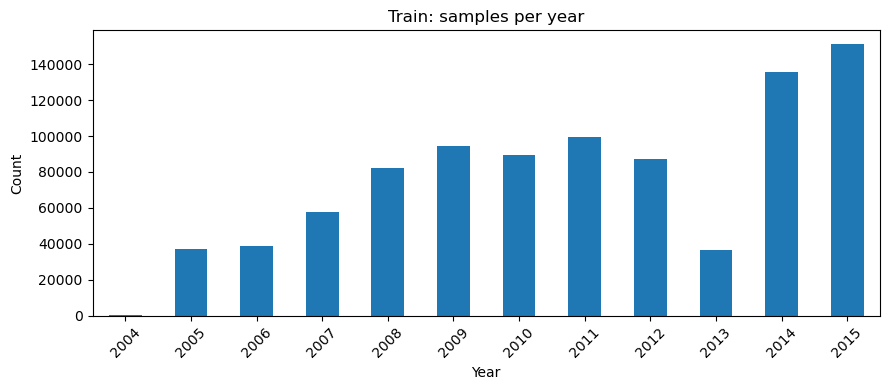


Validation year counts:
STUDY_DATE
2015       103
2016       374
2017    110970
2018     83138


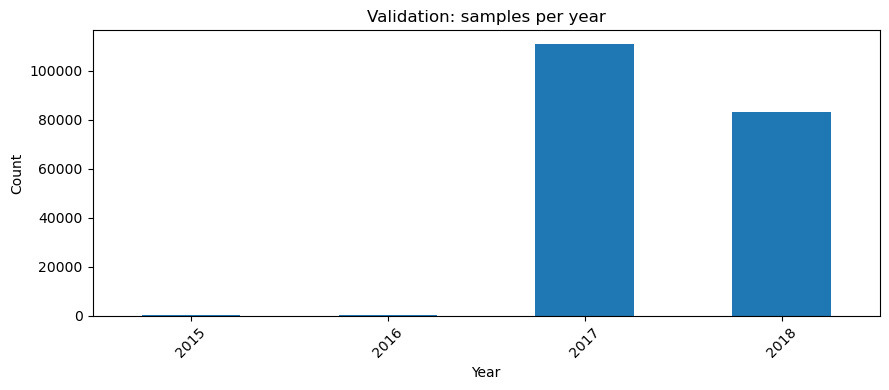


Test year counts:
STUDY_DATE
2018    195253


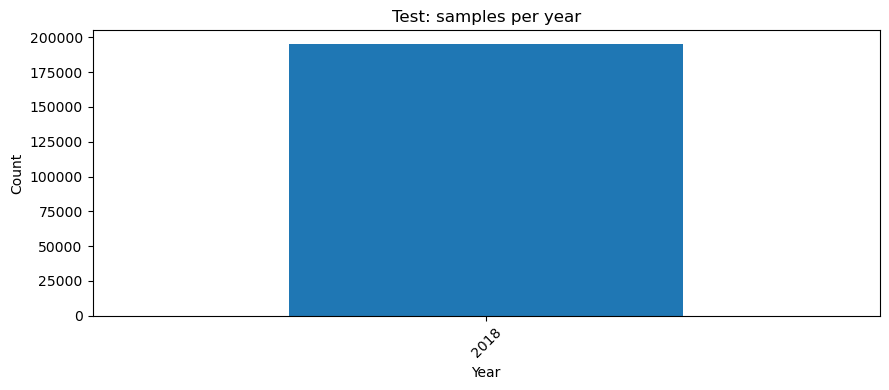

In [302]:
import matplotlib.pyplot as plt

date_col = "STUDY_DATE"
num_col  = f"{label_col}_numeric"

def year_hist(df, title):
    years = pd.to_datetime(df[date_col], errors="coerce").dt.year.dropna().astype(int)
    counts = years.value_counts().sort_index()

    # print table
    print(f"\n{title} year counts:")
    print(counts.to_string())

    # plot one chart per split
    plt.figure(figsize=(9,4))
    counts.plot(kind="bar")
    plt.title(f"{title}: samples per year")
    plt.xlabel("Year"); plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

year_hist(train_df, "Train")
year_hist(val_df,   "Validation")
year_hist(test_df,  "Test")